[2026-07-07 16:16:22] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-07 16:16:22] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-07 16:16:22] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-07 16:16:22] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-10-08 至 2024-12-31
[2026-07-07 16:16:22] [info     ] ========== 数据检查 ==========
[2026-07-07 16:16:22] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-09-24~2024-10-08,-0.0258

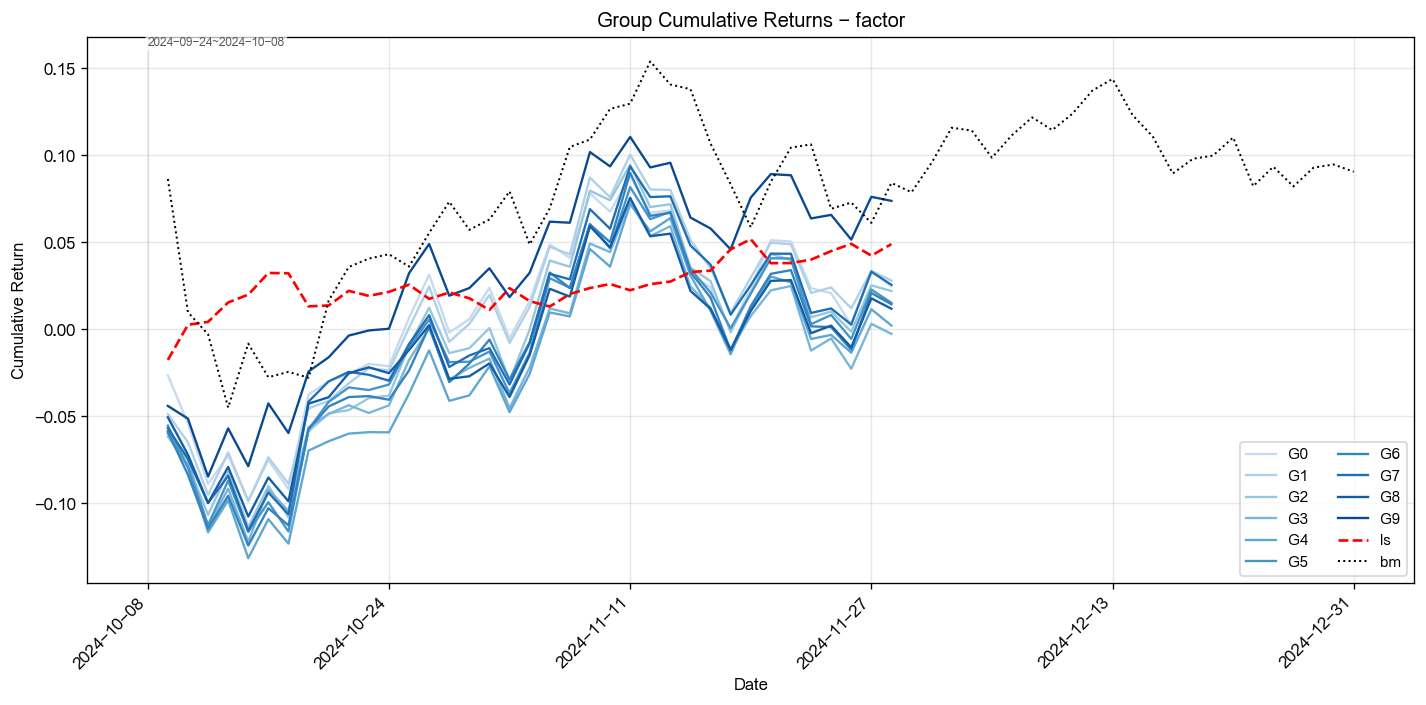
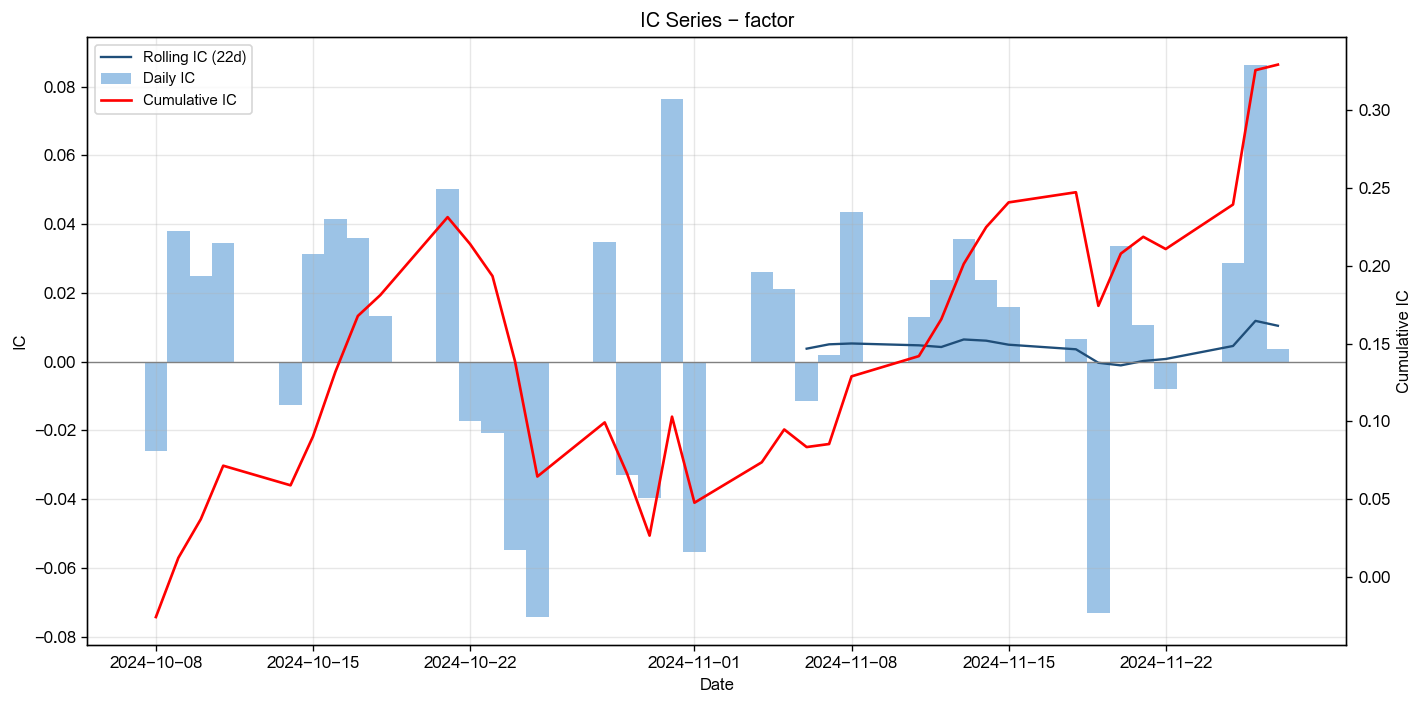
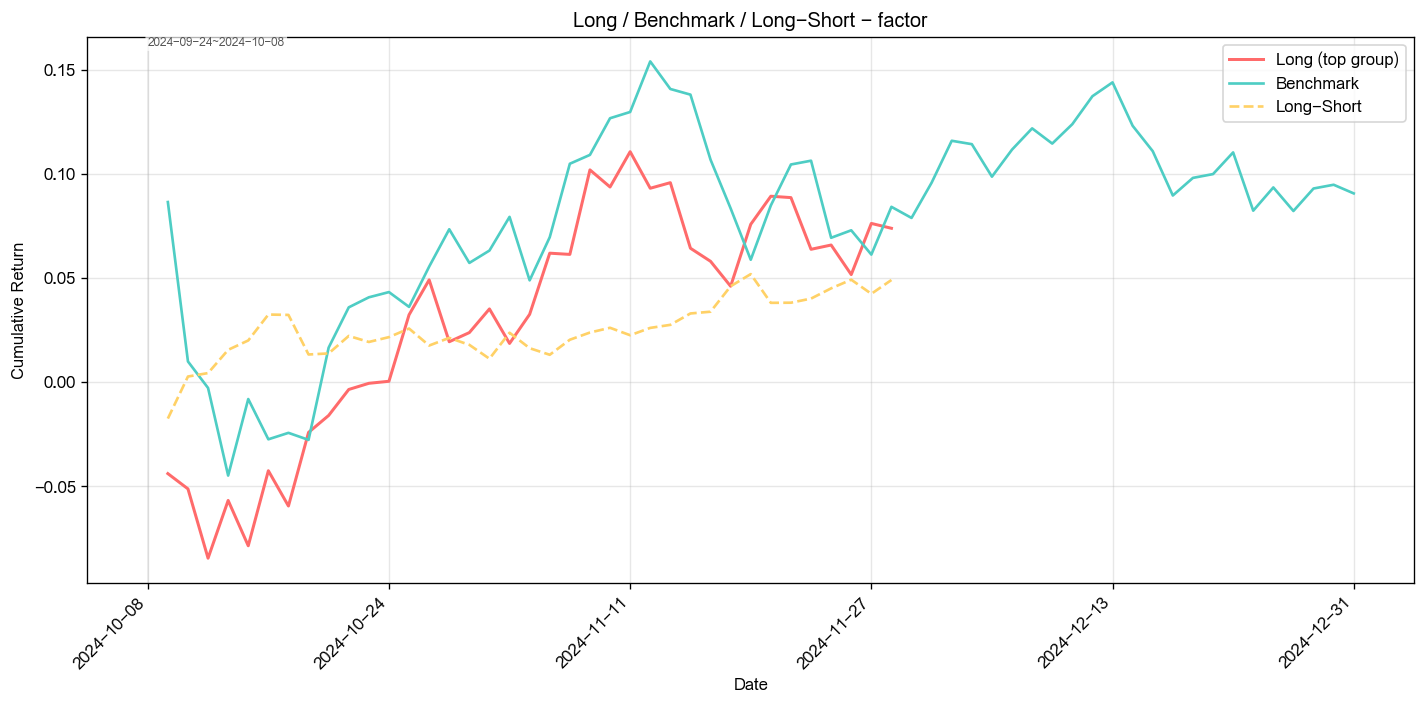
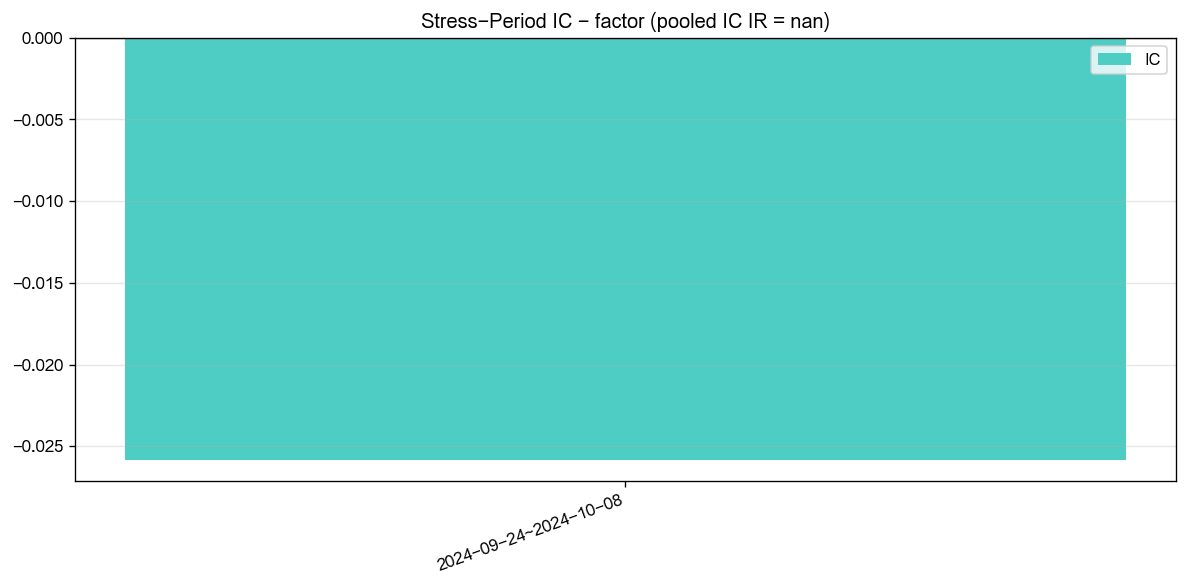
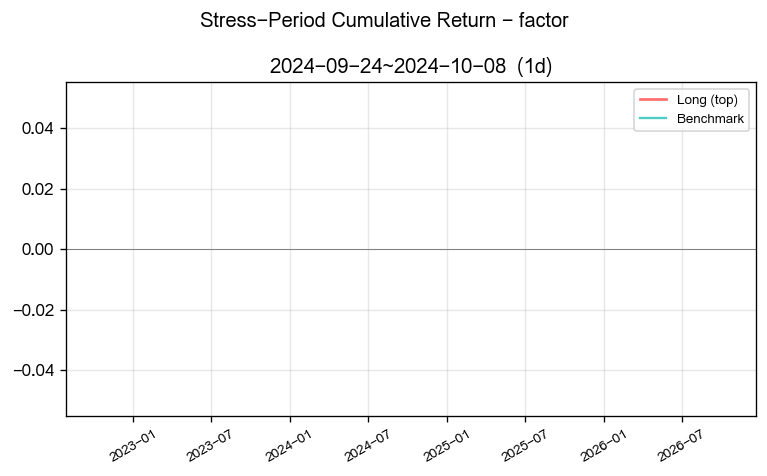

[2026-07-07 16:16:44] [info     ] ========== 因子池回归 ==========
[2026-07-07 16:16:44] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1100 rows=76237 start_date=2024-10-08
[2026-07-07 16:16:45] [info     ] 获取收益率数据, 耗时: 0.8665 秒
[2026-07-07 16:16:45] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.2501 秒
[2026-07-07 16:16:45] [info     ] 统计 回归结果, 耗时: 0.0047 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,8434260.7656,0.0843,0.0000,1.0000
2,kdj_k_9_3_3,5369794.6253,0.0537,0.0000,1.0000
3,bias_20,5099013.8571,0.0510,0.0000,1.0000
4,net_active_buy_amount_main,3307757.8481,0.0331,0.0000,1.0000
5,momentum_5,3061075.8353,0.0306,0.0000,1.0000
6,cci_14,3040539.2345,0.0304,0.0000,1.0000
7,daily_return,2215015.8961,0.0222,0.0000,1.0000
8,atr_14,2115629.7368,0.0212,0.0000,1.0000
9,macd_diff_12_26_9,2027312.4418,0.0203,0.0000,1.0000
10,netflow_amount_main,2017674.4495,0.0202,0.0000,1.0000

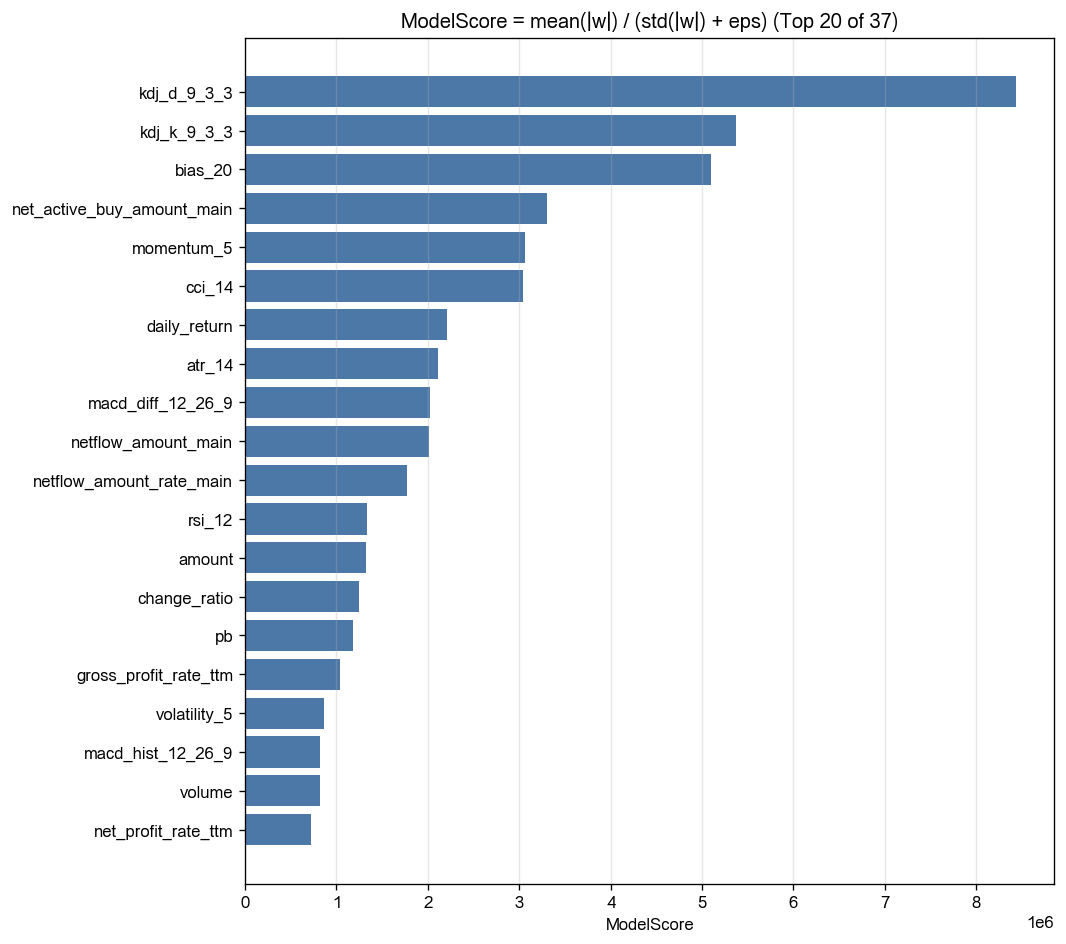
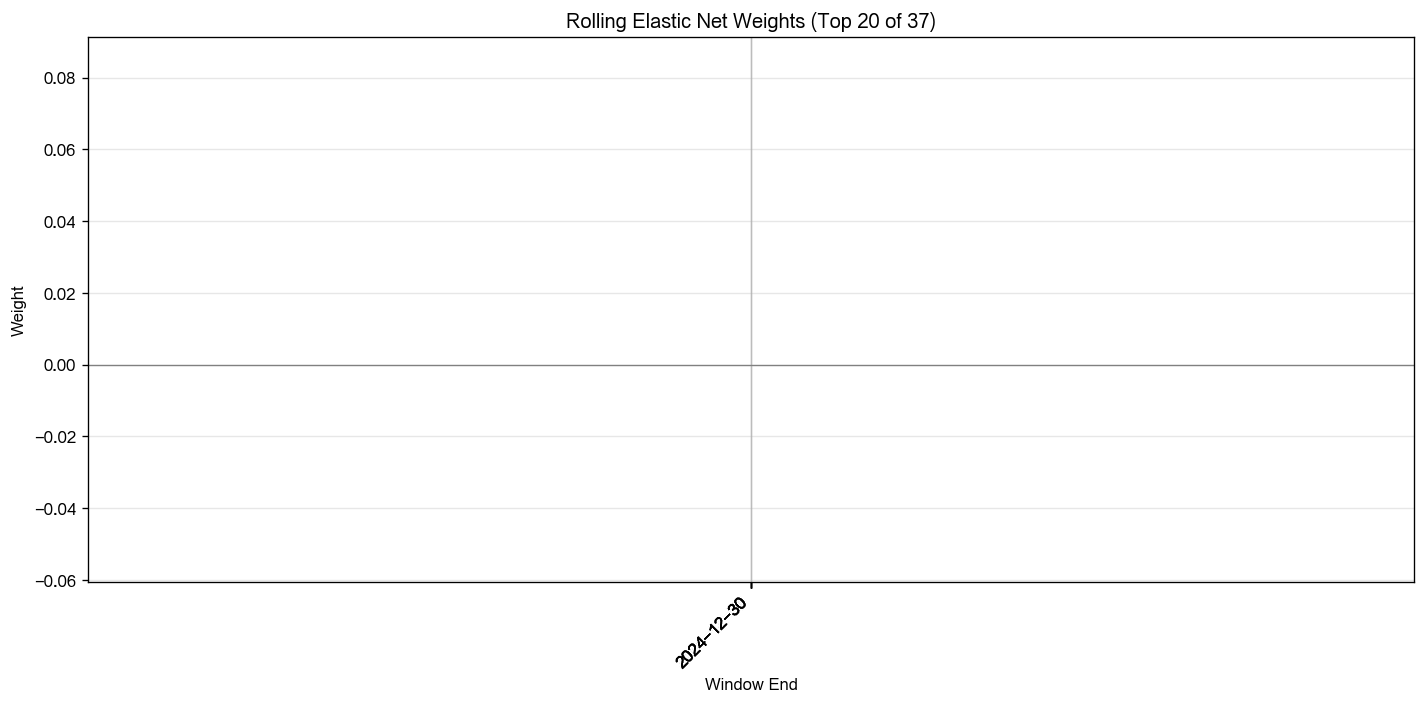
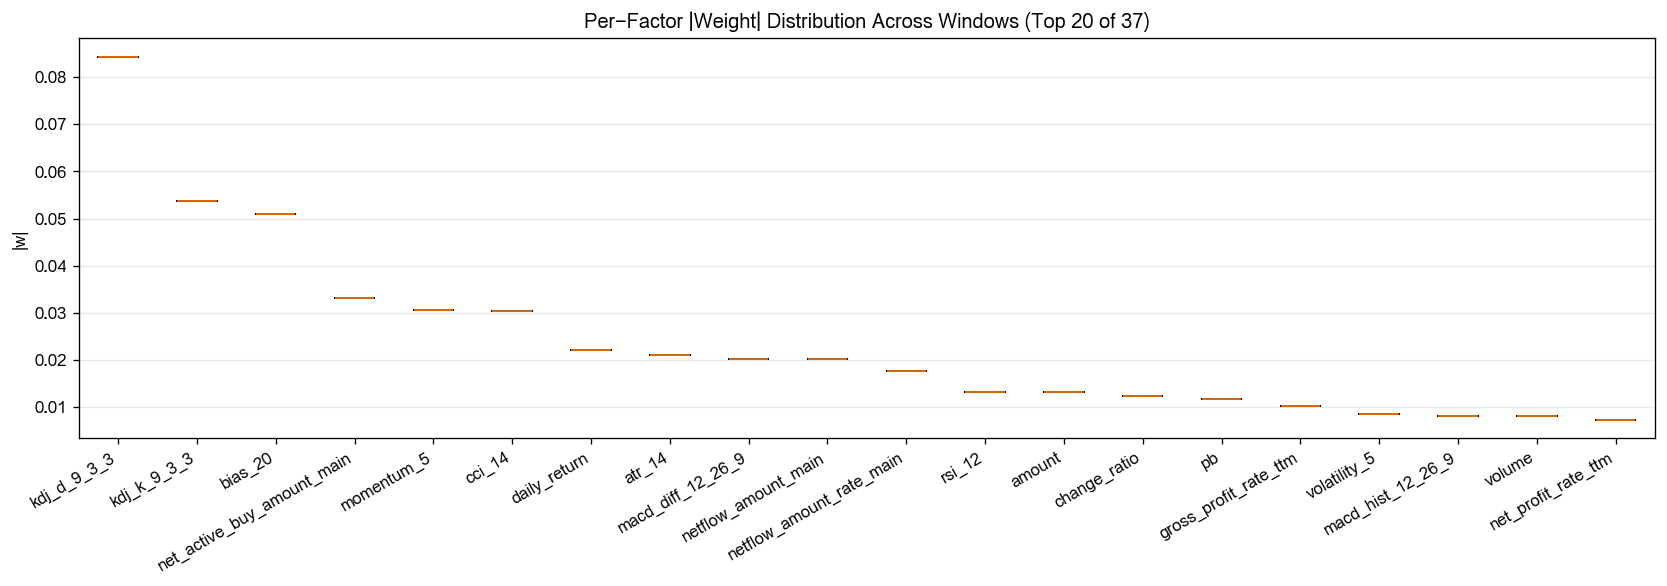
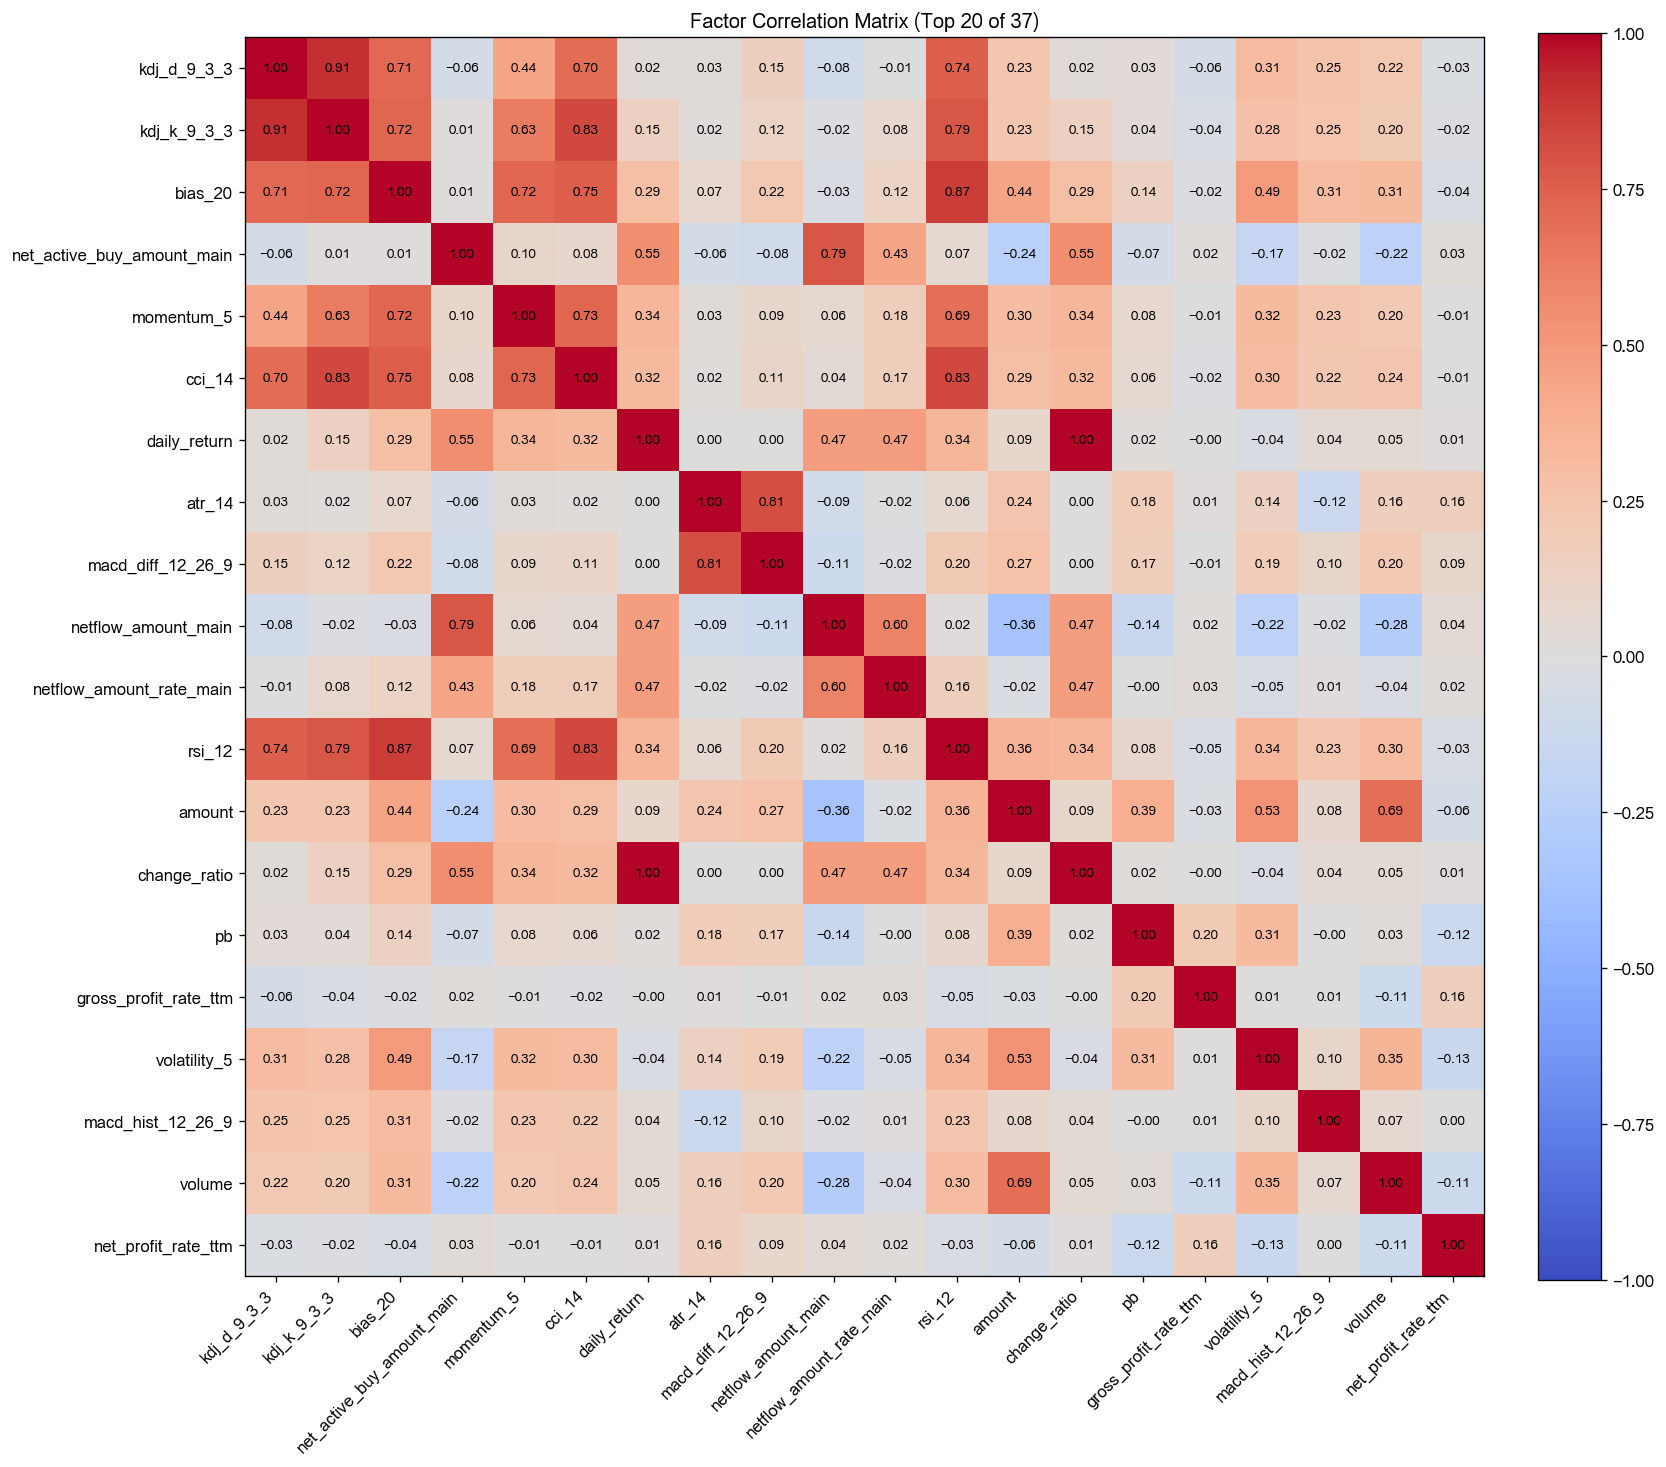

[2026-07-07 16:16:47] [warning  ] 返回的Outputs实例(size=13137584) 大于 64K, 将不会被缓存
[2026-07-07 16:16:47] [info     ] bigalpha_eval.v4 运行完成 [24.493s].


In [2]:
def main(datasources, start_date, end_date):
    """
    因子名称: 跳跃占比 (Jump Variation Ratio, JV/RV)
    赛道: 传统量化赛道

    经济逻辑:
        把当日已实现方差拆成"连续扩散"与"跳跃"两部分(Barndorff-Nielsen-
        Shephard):
          RV = Σ r²                          (已实现方差,含跳跃)
          BV = (π/2) · Σ |r_t|·|r_{t-1}|      (bipower 变差,对跳跃稳健→连续部分)
          JV = max(RV − BV, 0)               (跳跃方差)
          因子 = JV / RV                       (跳跃占总波动的份额)
        关键:因子是【无量纲的比值/成分】,不是波动率水平,故 BARRA 的
        RESVOL / BETA / LIQUIDTY 吃不掉它——这正是"做波动率结构而非水平"
        的开门处。分钟级日内跳跃占比几乎无人做,与已有微观结构因子同源不同轴。

    统计方法:
        - 5 分钟降采样(缓解分钟级买卖价跳动/微观结构噪声对 RV 的虚增)。
        - 按上午/下午分段计算收益与 bipower 相邻乘积,再合并 RV/BV,
          避免跨午休的伪收益污染。已用合成数据校验:BV 对跳跃稳健、
          分段配对与逐段直算一致。
        - 纯日内,每天重置,无跨日缓冲。

    数据源: bar1m(仅用 close)
    """
    import pandas as pd
    import numpy as np
    import dai

    # 方向:跳跃风险溢价的截面符号先验不定(可能正溢价,也可能过度反应→反转)。
    # 提交前看 factor_analyze.ic_mean,为负改 -1。
    SIGN = -1

    bar1m = datasources["bar1m"]

    CONT = ("strftime(date, '%H:%M:%S') >= '09:30:00' "
            "AND strftime(date, '%H:%M:%S') <= '15:00:00'")

    sql = f"""
    WITH px AS (
        SELECT
            date, instrument,
            strftime(date, '%Y-%m-%d') AS td,
            CASE WHEN strftime(date, '%H:%M:%S') <= '11:30:00'
                 THEN 'AM' ELSE 'PM' END AS sess,
            LN(close) AS lp
        FROM {bar1m}
        WHERE {CONT}
          AND CAST(strftime(date, '%M') AS INTEGER) % 5 = 0   -- 5 分钟采样点
          AND close > 0
    ),
    ret AS (
        SELECT date, instrument, td, sess,
            lp - LAG(lp) OVER (PARTITION BY instrument, td, sess ORDER BY date) AS r
        FROM px
    ),
    bp AS (
        SELECT date, instrument, td, sess, r,
            ABS(r) AS ar,
            LAG(ABS(r)) OVER (PARTITION BY instrument, td, sess ORDER BY date) AS ar_prev
        FROM ret
        WHERE r IS NOT NULL          -- 去掉每段首根(无 lag),LAG 在过滤后的行上配对
    ),
    daily AS (
        SELECT instrument, td,
            SUM(r * r) AS rv,
            (PI() / 2.0) * SUM(ar * ar_prev) AS bv,   -- ar_prev 段内首根为 NULL,SUM 自动跳过
            COUNT(r) AS n
        FROM bp
        GROUP BY instrument, td
    )
    SELECT
        CAST(td AS DATETIME) AS date,
        instrument,
        GREATEST(rv - bv, 0.0) / NULLIF(rv, 0) AS factor
    FROM daily
    WHERE n >= 10 AND rv > 0          -- 当日至少 10 根有效 5 分钟收益
    ORDER BY instrument, date
    """

    df = dai.query(
        sql, filters={'date': [start_date, end_date]}, compression=True
    ).df()

    df['instrument'] = df['instrument'].astype(str)
    df['date'] = pd.to_datetime(df['date'])
    df['factor'] = pd.to_numeric(df['factor'], errors='coerce').astype('float64')

    df['factor'] = SIGN * df['factor']
    df['factor'] = df['factor'].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return (df[['date', 'instrument', 'factor']]
            .sort_values(['date', 'instrument'])
            .reset_index(drop=True))


if __name__ == '__main__':
    from bigmodule import M
    import dai
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-10-01 00:00:00'
    end_date = '2024-12-31 23:59:59'
    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query("SELECT * FROM bigalpha_2026_factorlib",
                            filters={'date': [start_date, end_date]}).df()
    result = M.bigalpha_eval._latest(factor_data=factor_data, factor_pool=factor_pool,
                                     process_pools=False, show=True)